**Project 11: Smart City & Urban Sustainability Analytics Dashboard (SDG Goal 11: Sustainable Cities & Communities)**

INITIAL IMPORTS & DATA COLLECTION


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.cluster import KMeans

Environmental Data Collection

In [3]:
df_silk = pd.read_csv('/content/blr-btm-layout-cpcb-2024-25.csv')
df_hebbal = pd.read_csv('/content/blr-hebbal-kspcb-2024-25.csv')
df_btm = pd.read_csv('/content/blr-silk-board-kspcb-2024-25.csv')


In [4]:
df_silk['Station'], df_hebbal['Station'], df_btm['Station'] = 'Silk Board', 'Hebbal', 'BTM Layout'
master_aqi = pd.concat([df_silk, df_hebbal, df_btm], ignore_index=True)

DATA PRE-PROCESSING (Merging)

Time Formatting

In [5]:
master_aqi['Timestamp'] = pd.to_datetime(master_aqi['Timestamp'])
master_aqi['Hour'] = master_aqi['Timestamp'].dt.hour.fillna(0).astype(int)

Traffic Data Integration

In [6]:
traffic_mapping = {'Hebbal': 'Hebbal', 'Koramangala': 'Silk Board', 'Jayanagar': 'BTM Layout'}

traffic_df = pd.read_csv('/content/Banglore_traffic_Dataset.csv')


In [7]:
traffic_df['Station'] = traffic_df['Area Name'].map(traffic_mapping)



In [8]:
traffic_df = traffic_df.dropna(subset=['Station'])



In [9]:
traffic_df['Hour'] = pd.to_datetime(traffic_df['Date']).dt.hour

In [10]:
final_df_1 = pd.merge(master_aqi, traffic_df, on=['Station', 'Hour'], how='left')

Memory Optimization (Dropping heavy unnecessary columns)

In [11]:
essential_cols = ['Station', 'Hour', 'AQI', 'PM2.5 (µg/m³)', 'Traffic Volume', 'Average Speed', 'Public Transport Usage']


In [12]:
final_df_1 = final_df_1[[c for c in essential_cols if c in final_df_1.columns]].copy()
gc.collect()

0

Housing & Waste Data Mapping

In [13]:
manual_waste = {'Silk Board': 85.5, 'BTM Layout': 92.0, 'Hebbal': 78.5}
manual_water = {'Silk Board': 76.0, 'BTM Layout': 84.0, 'Hebbal': 72.0}

housing_map = {'HSR Layout': 'BTM Layout', 'BTM Layout': 'BTM Layout', 'Silk Board': 'Silk Board', 'Madiwala': 'Silk Board', 'Hebbal': 'Hebbal', 'Sahakar Nagar': 'Hebbal'}

In [14]:
housing_df = pd.read_csv('/content/Bengaluru_House_Data.csv')


In [15]:
housing_df['Station'] = housing_df['location'].map(housing_map)


In [16]:
housing_avg_dict = housing_df.dropna(subset=['Station']).groupby('Station')['price'].mean().to_dict()



In [17]:
final_df_1['Avg_Housing_Price'] = final_df_1['Station'].map(housing_avg_dict)
final_df_1['Waste_Score'] = final_df_1['Station'].map(manual_waste)
final_df_1['Water_Score'] = final_df_1['Station'].map(manual_water)

 DATA CLEANING

Downsampling for stability

In [18]:
if len(final_df_1) > 150000:
    final_df_1 = final_df_1.sample(n=150000, random_state=42).copy()

Handling Nulls


In [19]:
final_df_1['PM2.5 (µg/m³)'] = final_df_1['PM2.5 (µg/m³)'].fillna(final_df_1['PM2.5 (µg/m³)'].median())


In [20]:
traffic_cols = ['Traffic Volume', 'Average Speed', 'Public Transport Usage']
for col in traffic_cols:
    final_df_1[col] = final_df_1[col].fillna(final_df_1[col].median())

FEATURE ENGINEERING & TARGET VARIABLE

Normalizing Scores

In [21]:
final_df_1['AQI_Score'] = 1 - (final_df_1['PM2.5 (µg/m³)'] / final_df_1['PM2.5 (µg/m³)'].max())
final_df_1['Traffic_Score'] = final_df_1['Average Speed'] / final_df_1['Average Speed'].max()
final_df_1['Waste_Score_Norm'] = final_df_1['Waste_Score'] / final_df_1['Waste_Score'].max()



Sustainability Index (Target Variable Calculation)

In [22]:
final_df_1['Sustainability_Score'] = (final_df_1['AQI_Score'] * 0.3 +
                                      final_df_1['Traffic_Score'] * 0.3 +
                                      final_df_1['Waste_Score_Norm'] * 0.4)


In [23]:
final_df_1['Sustainability_Level'] = pd.cut(final_df_1['Sustainability_Score'],
                                            bins=[0, 0.4, 0.7, 1.0],
                                            labels=['Low', 'Medium', 'High'])

Risk Score

In [24]:
final_df_1['Risk_Score'] = (final_df_1['PM2.5 (µg/m³)'] / final_df_1['PM2.5 (µg/m³)'].max()) + \
                           (final_df_1['Traffic Volume'] / final_df_1['Traffic Volume'].max())



SEGMENTATION (Clustering)

In [25]:
X_cluster = final_df_1[['PM2.5 (µg/m³)', 'Traffic Volume', 'Waste_Score']]



In [26]:
kmeans = KMeans(n_clusters=3, random_state=42)


In [27]:
final_df_1['Urban_Zone_Cluster'] = kmeans.fit_predict(X_cluster)

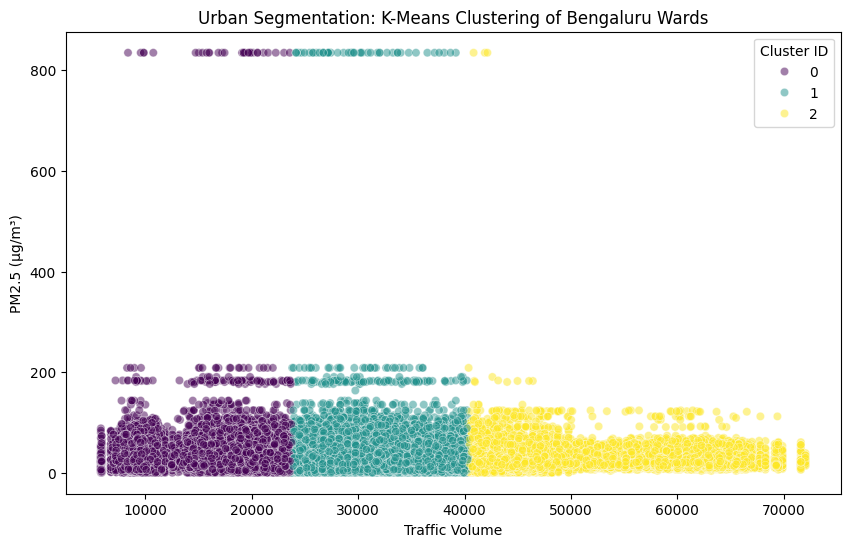

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(data=final_df_1, x='Traffic Volume', y='PM2.5 (µg/m³)',
                hue='Urban_Zone_Cluster', palette='viridis', alpha=0.5)

plt.title('Urban Segmentation: K-Means Clustering of Bengaluru Wards')
plt.xlabel('Traffic Volume')
plt.ylabel('PM2.5 (µg/m³)')
plt.legend(title='Cluster ID')
plt.show()


MODEL PREDICTION (Random Forest)

In [28]:
X = final_df_1[['PM2.5 (µg/m³)', 'Traffic Volume', 'Average Speed', 'Public Transport Usage', 'Waste_Score', 'Avg_Housing_Price']]
y = final_df_1['Sustainability_Level']

In [29]:


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [30]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)



RandomForestClassifier(random_state=42)

In [31]:
y_pred = model.predict(X_test)


In [32]:
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

Model Accuracy: 99.99%


FEATURE IMPORTANCE & EXPORTS

Visualize Importance

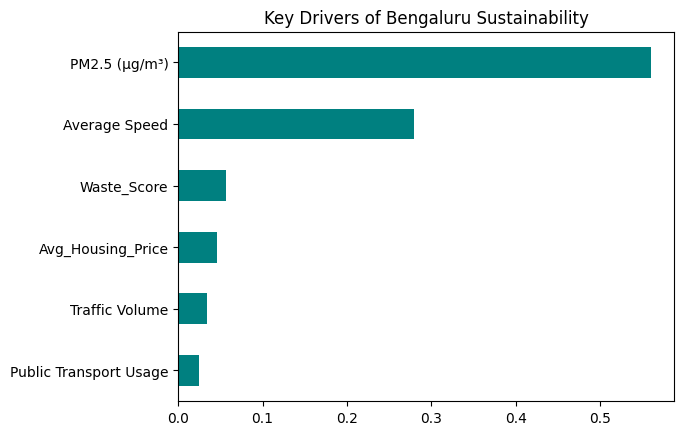

In [33]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', title='Key Drivers of Bengaluru Sustainability', color='teal')
plt.show()

Export Final CSVs

In [34]:
final_df_1.to_csv('Bengaluru_SDG11_Final_Project.csv', index=False)


KPI & Model Performance Export

In [35]:
kpi_summary = final_df_1.groupby('Station').agg({
    'PM2.5 (µg/m³)': 'mean', 'Average Speed': 'mean',
    'Public Transport Usage': 'mean', 'Waste_Score': 'mean', 'Sustainability_Score': 'mean'
}).reset_index()


kpi_summary.to_csv('SDG11_KPI_Metrics.csv', index=False)

INSIGHTS & EDA VISUALS

Pollution Distribution

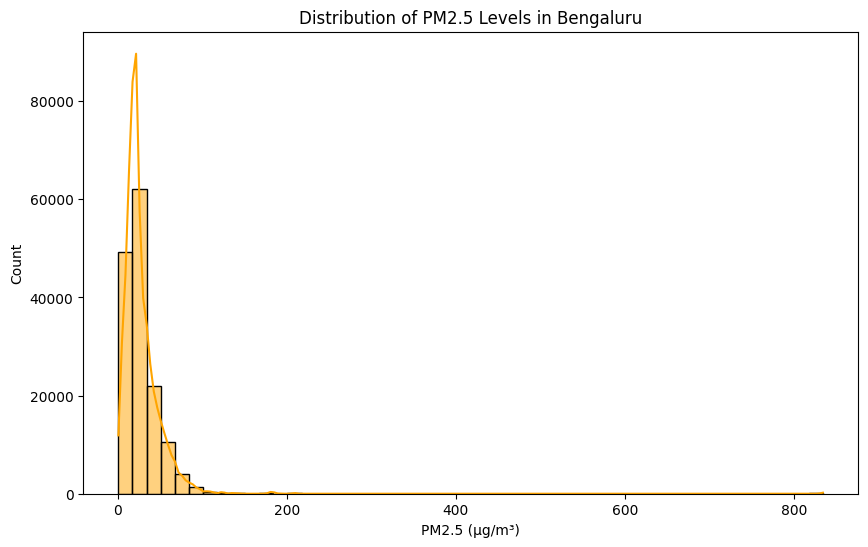

In [36]:
plt.figure(figsize=(10, 6))
sns.histplot(final_df_1['PM2.5 (µg/m³)'], bins=50, kde=True, color='orange')
plt.title('Distribution of PM2.5 Levels in Bengaluru')
plt.show()

Traffic vs Population Trends

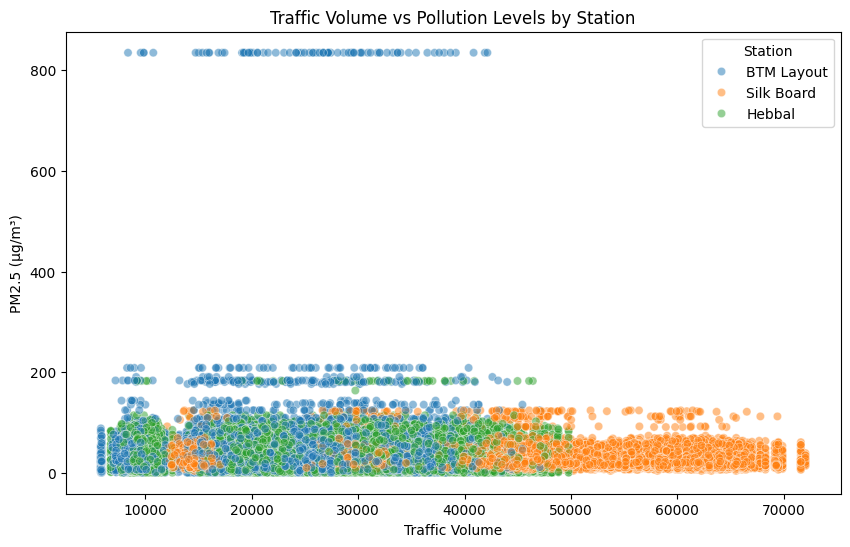

In [37]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=final_df_1, x='Traffic Volume', y='PM2.5 (µg/m³)', hue='Station', alpha=0.5)
plt.title('Traffic Volume vs Pollution Levels by Station')
plt.show()

CROSS -CHECK ( K-Fold Cross-Validation)

In [38]:
from sklearn.model_selection import cross_val_score

X = final_df_1[['PM2.5 (µg/m³)', 'Traffic Volume', 'Average Speed', 'Waste_Score']]
y = final_df_1['Sustainability_Level']


scores = cross_val_score(model, X, y, cv=5)

print(f"Accuracy for each fold: {scores}")
print(f"Average Accuracy across all folds: {scores.mean() * 100:.2f}%")


Accuracy for each fold: [0.99986667 1.         0.99993333 0.99993333 0.99993333]
Average Accuracy across all folds: 99.99%
